In [23]:
import pandas as pd

# 1. Load the newly saved file
file_path = 'df_bookings_metros_filtered_withregion_toddow.parquet'
df_final = pd.read_parquet(file_path)

# 2. Calculate Percentage Distribution for TOD
tod_distribution = df_final['TOD'].value_counts(normalize=True).sort_index() * 100

print(f"📊 TOD % Distribution (Source: {file_path})")
print("-" * 50)
print(tod_distribution.map("{:.2f}%".format))
print("-" * 50)
print(f"Total Rows: {len(df_final):,}")
df_final.head(5)
print(df_final.columns.tolist())

📊 TOD % Distribution (Source: df_bookings_metros_filtered_withregion_toddow.parquet)
--------------------------------------------------
TOD
00:00-06:59     0.85%
07:00-09:59    21.69%
10:00-12:59    33.15%
13:00-15:59    26.03%
16:00-18:59    13.79%
19:00-23:59     4.48%
Name: proportion, dtype: object
--------------------------------------------------
Total Rows: 115,071
['flightId', 'atlasreservationid', 'flightStatus', 'legOrder', 'flightoriginAirportId', 'flightoriginAirport', 'flightoriginAirportName', 'flightoriginAirportCity', 'flightoriginAirportState', 'flightoriginAirportCountry', 'flightdestinationAirportId', 'flightdestinationAirport', 'flightdestinationAirportName', 'flightdestinationAirportCity', 'flightdestinationAirportState', 'flightdestinationAirportCountry', 'flightEstimatedDepartureTime', 'flightEstimatedArrivalTime', 'flightEstimatedFlightHours', 'flightEstimatedBilledHours', 'flightActualDepartureTime', 'flightActualArrivalTime', 'flightActualFlightHours', 'flight

In [15]:
import json
import pandas as pd

# 1. Load the JSON from GCS (using the joined string fix from before)
path = 'gs://agntworks-data-dev/wheelsup/processed/tod_dow_overrides.json'
json_raw = !gsutil cat {path}
json_string = "".join(json_raw)

try:
    full_data = json.loads(json_string)
    
    # 2. Extract ONLY the 'overrides' list for the DataFrame
    # This avoids the "meta" dictionary conflict
    df_overrides = pd.DataFrame(full_data['overrides'])

    # 3. Handle Geography: Flatten the nested dictionary into strings
    # This prevents merge errors and allows us to see the conditions clearly
    def flatten_geo(val):
        if isinstance(val, dict):
            return f"{val.get('origin_region')} to {val.get('destination_region')}"
        return None

    df_overrides['geo_summary'] = df_overrides['geography_condition'].apply(flatten_geo)

    # 4. DEDUPLICATION: Strict rule - one adjustment per row
    df_overrides = df_overrides.drop_duplicates(subset=['cabin', 'day_of_week', 'time_slot', 'geo_summary'])

    print(f"✅ Successfully loaded {len(df_overrides)} unique override rules.")
    display(df_overrides.head(10))

except Exception as e:
    print(f"❌ Error: {e}")

# Strategy Check:
print("\nUnique Cabins in JSON:", df_overrides['cabin'].unique())
print("Specific Geography Rules found:", df_overrides['geo_summary'].notna().sum())

✅ Successfully loaded 86 unique override rules.


,cabin,day_of_week,time_slot,adjustment_pct,geography_condition,geo_summary
0,Light,Tuesday,10:00-12:59,15,NaN,None
1,Light,Wednesday,10:00-12:59,15,NaN,None
2,Light,Saturday,10:00-12:59,15,NaN,None
3,Light,Monday,10:00-12:59,25,NaN,None
4,Light,Thursday,10:00-12:59,25,NaN,None
5,Light,Friday,10:00-12:59,25,NaN,None
6,Light,Sunday,10:00-12:59,25,NaN,None
7,Light,Thursday,13:00-15:59,15,NaN,None
8,Light,Friday,13:00-15:59,15,NaN,None
9,Light,Sunday,13:00-15:59,15,NaN,None



Unique Cabins in JSON: ['Light' 'Super Midsize' 'Premium Light' 'Premium Super-Mid']
Specific Geography Rules found: 21


In [16]:
# Set pandas to show all rows so you can scroll through the full 86
pd.set_option('display.max_rows', 100)

# Display the columns relevant to your audit
display(df_overrides[['cabin', 'day_of_week', 'time_slot', 'adjustment_pct', 'geo_summary']])

# Reset to default after viewing
pd.reset_option('display.max_rows')

,cabin,day_of_week,time_slot,adjustment_pct,geo_summary
0,Light,Tuesday,10:00-12:59,15,None
1,Light,Wednesday,10:00-12:59,15,None
2,Light,Saturday,10:00-12:59,15,None
3,Light,Monday,10:00-12:59,25,None
4,Light,Thursday,10:00-12:59,25,None
5,Light,Friday,10:00-12:59,25,None
6,Light,Sunday,10:00-12:59,25,None
7,Light,Thursday,13:00-15:59,15,None
8,Light,Friday,13:00-15:59,15,None
9,Light,Sunday,13:00-15:59,15,None


In [30]:
# --- INITIALIZATION ---
if 'final_adjustment_pct' in df_final.columns:
    df_final = df_final.drop(columns=['final_adjustment_pct'])

# 1. PASS 1: GLOBAL BASELINE
df_global = df_overrides[df_overrides['geo_summary'].isna()].copy()

df_final = df_final.merge(
    df_global[['cabin', 'day_of_week', 'time_slot', 'adjustment_pct']], 
    left_on=['flightactualAircraftCabinName', 'DOW', 'TOD'], 
    right_on=['cabin', 'day_of_week', 'time_slot'], 
    how='left'
)

df_final = df_final.rename(columns={'adjustment_pct': 'final_adjustment_pct'})
df_final = df_final.drop(columns=[c for c in ['cabin', 'day_of_week', 'time_slot'] if c in df_final.columns])
df_final['final_adjustment_pct'] = df_final['final_adjustment_pct'].fillna(0)

print(f"✅ Pass 1 Complete: Global baseline applied.")

# 2. PASS 2: REGIONAL OVERWRITE (Southwest -> East Coast)
df_regional = df_overrides[df_overrides['geo_summary'].notna()].copy()

regional_mask = (
    (df_final['flightoriginAirportRegion'] == 'Southwest') & 
    (df_final['flightdestinationAirportRegion'] == 'East Coast')
)

for _, rule in df_regional.iterrows():
    rule_match = (
        regional_mask & 
        (df_final['flightactualAircraftCabinName'] == rule['cabin']) & 
        (df_final['DOW'] == rule['day_of_week']) & 
        (df_final['TOD'] == rule['time_slot'])
    )
    if rule_match.any():
        df_final.loc[rule_match, 'final_adjustment_pct'] = rule['adjustment_pct']

print(f"✅ Pass 2 Complete: Regional overrides applied.")

# --- FINAL VALIDATION ---
print("\n📊 Final Single-Column Distribution:")
print(df_final['final_adjustment_pct'].value_counts().sort_index())
assert len(df_final) == 115071, "Row count changed!"

print(f"📊 Pre-Merge Rows:  115,071")
print(f"📊 Post-Merge Rows: {len(df_final):,}")
print(f"💎 Row Integrity:   {'PASSED' if len(df_final) == 115071 else 'FAILED'}")

✅ Pass 1 Complete: Global baseline applied.
✅ Pass 2 Complete: Regional overrides applied.

📊 Final Single-Column Distribution:
final_adjustment_pct
0.0      61592
5.0       1995
15.0     28755
25.0     21749
100.0      980
Name: count, dtype: int64
📊 Pre-Merge Rows:  115,071
📊 Post-Merge Rows: 115,071
💎 Row Integrity:   PASSED


In [31]:
# Define the destination path in GCS
destination_path = 'gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.parquet'

# Write to Parquet using the fastparquet or pyarrow engine
try:
    df_final.to_parquet(destination_path, index=False)
    print(f"✅ Successfully wrote {len(df_final):,} rows to GCS:")
    print(f"📍 {destination_path}")
except Exception as e:
    print(f"❌ Error writing to GCS: {e}")

✅ Successfully wrote 115,071 rows to GCS:
📍 gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.parquet


In [34]:
# 1. Calculate Revenue Lift for each row
df_final['revenue_lift'] = df_final['flightcost'] * (df_final['final_adjustment_pct'] / 100)

# 2. Group by Adjustment % to get counts and revenue sums
agg_stats = df_final.groupby('final_adjustment_pct').agg(
    row_count=('final_adjustment_pct', 'count'),
    total_revenue_lift=('revenue_lift', 'sum')
).reset_index()

# 3. Calculate Percentages
total_rows = len(df_final)
total_lift = agg_stats['total_revenue_lift'].sum()

agg_stats['% of Total Rows'] = (agg_stats['row_count'] / total_rows) * 100
agg_stats['% of Total Revenue Lift'] = (agg_stats['total_revenue_lift'] / total_lift) * 100

# 4. Formatting for display
display_stats = agg_stats.copy()
display_stats['row_count'] = display_stats['row_count'].apply(lambda x: f"{x:,}")
display_stats['total_revenue_lift'] = display_stats['total_revenue_lift'].apply(lambda x: f"${x:,.2f}")
display_stats['% of Total Rows'] = display_stats['% of Total Rows'].map("{:.2f}%".format)
display_stats['% of Total Revenue Lift'] = display_stats['% of Total Revenue Lift'].map("{:.2f}%".format)

display_stats.columns = ['Adjustment %', 'Row Count', 'Revenue Lift ($)', '% of Total Rows', '% of Revenue Lift']

print(f"💰 Revenue Impact Analysis (Total Flights: {total_rows:,})")
print("-" * 80)
display(display_stats)

print("-" * 80)
print(f"🚀 Total New Revenue Generated: ${total_lift:,.2f}")

💰 Revenue Impact Analysis (Total Flights: 115,071)
--------------------------------------------------------------------------------


,Adjustment %,Row Count,Revenue Lift ($),% of Total Rows,% of Revenue Lift
0,0.0,"61,592",$0.00,53.53%,0.00%
1,5.0,"1,995","$3,330,747.27",1.73%,1.70%
2,15.0,"28,755","$74,972,864.85",24.99%,38.22%
3,25.0,"21,749","$101,040,732.08",18.90%,51.51%
4,100.0,980,"$16,830,965.14",0.85%,8.58%


--------------------------------------------------------------------------------
🚀 Total New Revenue Generated: $196,175,309.34


📊 TOD Volume Analysis (Total Rows: 115,071)
--------------------------------------------------


,Flight Count,% of Total
TOD,,
00:00-06:59,980,0.85%
07:00-09:59,"24,963",21.69%
10:00-12:59,"38,144",33.15%
13:00-15:59,"29,957",26.03%
16:00-18:59,"15,870",13.79%
19:00-23:59,"5,157",4.48%


<Axes: title={'center': 'Flight Volume by TOD'}, xlabel='TOD'>

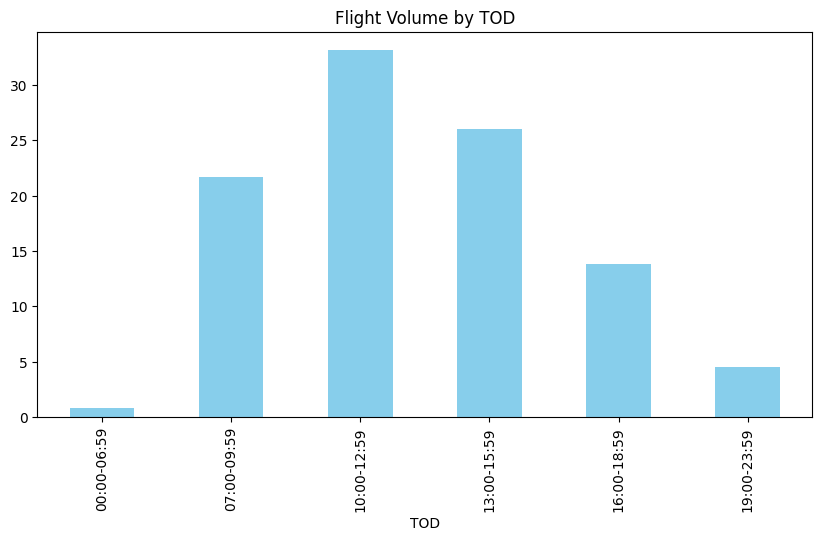

In [33]:
# 1. Calculate the TOD distribution
tod_counts = df_final['TOD'].value_counts().sort_index()
tod_pcts = df_final['TOD'].value_counts(normalize=True).sort_index() * 100

# 2. Combine into a summary table
tod_summary = pd.DataFrame({
    'Flight Count': tod_counts,
    '% of Total': tod_pcts
})

# 3. Format and display
print(f"📊 TOD Volume Analysis (Total Rows: {len(df_final):,})")
print("-" * 50)
display(tod_summary.style.format({'Flight Count': '{:,}', '% of Total': '{:.2f}%'}))

# 4. Optional: Quick plot to visualize the curve
tod_summary['% of Total'].plot(kind='bar', color='skyblue', figsize=(10, 5), title='Flight Volume by TOD')

In [2]:
import pandas as pd

# 1. Read the finalized parquet file from GCS
source_path = 'gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.parquet'
csv_destination_path = 'gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.csv'

print(f"🔄 Reading source: {source_path}")

try:
    # Load the data
    df_final = pd.read_parquet(source_path)
    
    # 2. Save as CSV
    print(f"💾 Saving to CSV...")
    df_final.to_csv(csv_destination_path, index=False)
    
    print(f"✅ Success! Saved {len(df_final):,} rows.")
    print(f"📍 Location: {csv_destination_path}")

except Exception as e:
    print(f"❌ Error: {e}")

🔄 Reading source: gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.parquet
💾 Saving to CSV...


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


✅ Success! Saved 115,071 rows.
📍 Location: gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.csv


In [1]:
import pandas as pd

# 1. Re-import the finalized parquet
path = 'gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.parquet'
df_check = pd.read_parquet(path)

# 2. Identify any suffix or helper columns
suffixes = [c for c in df_check.columns if c.endswith('_x') or c.endswith('_y')]
helpers = [c for c in ['cabin', 'day_of_week', 'time_slot'] if c in df_check.columns]

print(f"✅ Total Columns: {len(df_check.columns)}")
print(f"⚠️ Suffix Columns found: {suffixes if suffixes else 'None'}")
print(f"⚠️ Helper Columns found: {helpers if helpers else 'None'}")

# 3. List all columns for a final check
print("\n📋 Full Column List:")
print(df_check.columns.tolist())

✅ Total Columns: 60
⚠️ Suffix Columns found: ['cabin_x', 'day_of_week_x', 'time_slot_x', 'adjustment_pct_x', 'cabin_y', 'day_of_week_y', 'time_slot_y', 'adjustment_pct_y']
⚠️ Helper Columns found: None

📋 Full Column List:
['flightId', 'atlasreservationid', 'flightStatus', 'legOrder', 'flightoriginAirportId', 'flightoriginAirport', 'flightoriginAirportName', 'flightoriginAirportCity', 'flightoriginAirportState', 'flightoriginAirportCountry', 'flightdestinationAirportId', 'flightdestinationAirport', 'flightdestinationAirportName', 'flightdestinationAirportCity', 'flightdestinationAirportState', 'flightdestinationAirportCountry', 'flightEstimatedDepartureTime', 'flightEstimatedArrivalTime', 'flightEstimatedFlightHours', 'flightEstimatedBilledHours', 'flightActualDepartureTime', 'flightActualArrivalTime', 'flightActualFlightHours', 'flightActualBilledHours', 'flightrequestedAircraftType', 'flightrequestedAircraftCabinId', 'flightrequestedAircraftCabinName', 'flightrequestedAircraftTypeId'

In [2]:
# Validation: Check why final_adjustment_pct is potentially missing data
validation_df = df_check[['adjustment_pct_x', 'adjustment_pct_y', 'final_adjustment_pct']].copy()

# 1. Check populations
print(f"Total Rows: {len(df_check):,}")
print("-" * 30)
print(f"Rows with Global Match (_x):   {df_check['adjustment_pct_x'].notna().sum():,}")
print(f"Rows with Regional Match (_y): {df_check['adjustment_pct_y'].notna().sum():,}")
print(f"Rows where Final is 0.0:       {(df_check['final_adjustment_pct'] == 0).sum():,}")

# 2. Check for "Lost" Data
# Rows where we have a match in x or y but the final column is still 0
lost_global = df_check[(df_check['adjustment_pct_x'].notna()) & (df_check['final_adjustment_pct'] == 0)]
lost_regional = df_check[(df_check['adjustment_pct_y'].notna()) & (df_check['final_adjustment_pct'] == 0)]

print("-" * 30)
print(f"❌ Lost Global Adjustments:   {len(lost_global):,}")
print(f"❌ Lost Regional Adjustments: {len(lost_regional):,}")

# 3. Sample of the discrepancy
if len(lost_global) > 0 or len(lost_regional) > 0:
    print("\n🔍 Sample of problematic rows:")
    display(df_check[df_check['adjustment_pct_x'].notna() | df_check['adjustment_pct_y'].notna()].head(10))

Total Rows: 115,071
------------------------------
Rows with Global Match (_x):   23,874
Rows with Regional Match (_y): 53,479
Rows where Final is 0.0:       61,592
------------------------------
❌ Lost Global Adjustments:   23,874
❌ Lost Regional Adjustments: 0

🔍 Sample of problematic rows:


,flightId,atlasreservationid,flightStatus,legOrder,flightoriginAirportId,flightoriginAirport,flightoriginAirportName,flightoriginAirportCity,flightoriginAirportState,flightoriginAirportCountry,...,flightEstimatedDepartureTime_ET,cabin_x,day_of_week_x,time_slot_x,adjustment_pct_x,cabin_y,day_of_week_y,time_slot_y,adjustment_pct_y,final_adjustment_pct
0,1208330,794521,Flown,1,333,KPBI,Palm Beach International,West Palm Beach,FL,US,...,2024-04-04 10:59:00,None,None,None,NaN,Super Midsize,Thursday,10:00-12:59,25.0,25.0
1,1208345,794531,Flown,1,810,KTEB,Teterboro,Teterboro,NJ,US,...,2024-04-07 13:30:00,None,None,None,NaN,Super Midsize,Sunday,13:00-15:59,15.0,15.0
4,1208372,794548,Flown,2,1026,KBCT,Boca Raton,Boca Raton,FL,US,...,2024-04-21 12:00:00,None,None,None,NaN,Light,Sunday,10:00-12:59,25.0,25.0
5,1208381,794555,Flown,2,815,KJKA,Gulf Shores International Jack Edwards Field,Gulf Shores,AL,US,...,2024-04-26 11:15:00,None,None,None,NaN,Light,Friday,10:00-12:59,25.0,25.0
7,1208389,794562,Flown,1,1407,KSSI,St Simons Island,Brunswick,GA,US,...,2024-06-17 08:00:00,Light,Monday,07:00-09:59,25.0,None,None,None,NaN,0.0
8,1208392,794564,Flown,1,333,KPBI,Palm Beach International,West Palm Beach,FL,US,...,2024-04-17 09:00:00,Light,Wednesday,07:00-09:59,15.0,None,None,None,NaN,0.0
10,1208447,794599,Flown,1,93,KAUS,Austin Bergstrom International,Austin,TX,US,...,2024-05-02 11:00:00,None,None,None,NaN,Light,Thursday,10:00-12:59,25.0,25.0
11,1208448,794600,Flown,1,322,KCLT,Charlotte Douglas International,Charlotte,NC,US,...,2024-05-18 10:00:00,None,None,None,NaN,Light,Saturday,10:00-12:59,15.0,15.0
13,1208464,794611,Flown,1,1262,KIKK,Greater Kankakee,Kankakee,IL,US,...,2024-04-16 08:00:00,Light,Tuesday,07:00-09:59,15.0,None,None,None,NaN,0.0
14,1208466,794612,Flown,2,565,KBQK,Brunswick Golden Isles,Brunswick,GA,US,...,2024-06-08 12:42:00,None,None,None,NaN,Light,Saturday,10:00-12:59,15.0,15.0


In [3]:
# 1. Identify rows where both global (_x) and regional (_y) matches exist
overlap_df = df_check[df_check['adjustment_pct_x'].notna() & df_check['adjustment_pct_y'].notna()]

overlap_count = len(overlap_df)

print(f"🔍 Overlap Analysis")
print("-" * 30)
print(f"Total Rows in Data:            {len(df_check):,}")
print(f"Rows with BOTH x and y values: {overlap_count:,}")

# 2. Display examples if they exist to see the values
if overlap_count > 0:
    print("\n💡 Example of overlapping rules:")
    display(overlap_df[['flightactualAircraftCabinName', 'DOW', 'TOD', 'adjustment_pct_x', 'adjustment_pct_y']].head(5))
else:
    print("\n✅ No overlaps found. Every flight matched either a Global rule, a Regional rule, or nothing at all.")

🔍 Overlap Analysis
------------------------------
Total Rows in Data:            115,071
Rows with BOTH x and y values: 0

✅ No overlaps found. Every flight matched either a Global rule, a Regional rule, or nothing at all.


In [5]:
# 1. Use df_check (which you already loaded) to create the clean df_final
df_final = df_check.copy()

# 2. Consolidate x and y into the final column
# Since there is 0 overlap, addition is mathematically the same as a priority fill
df_final['final_adjustment_pct'] = df_final['adjustment_pct_x'].fillna(0) + df_final['adjustment_pct_y'].fillna(0)

# 3. Identify and drop the suffix columns (_x, _y)
cols_to_drop = [c for c in df_final.columns if c.endswith('_x') or c.endswith('_y')]
df_final = df_final.drop(columns=cols_to_drop)

# --- Verification ---
print(f"✅ Reconciliation Complete.")
print(f"📊 Final Adjustment Distribution (Total Rows: {len(df_final):,})")
print(df_final['final_adjustment_pct'].value_counts().sort_index())

# 4. Save the corrected versions to GCS
pq_path = 'gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.parquet'
csv_path = 'gs://agntworks-data-dev/wheelsup/processed/df_bookings_metros_final_merge.csv'

df_final.to_parquet(pq_path, index=False)
df_final.to_csv(csv_path, index=False)

print(f"\n🚀 Files successfully rewritten to GCS with no suffixes.")

✅ Reconciliation Complete.
📊 Final Adjustment Distribution (Total Rows: 115,071)
final_adjustment_pct
0.0      37718
5.0       1995
15.0     38853
25.0     35525
100.0      980
Name: count, dtype: int64


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)



🚀 Files successfully rewritten to GCS with no suffixes.


In [6]:
# 1. Group by Adjustment % to get counts and total revenue sums
agg_stats = df_final.groupby('final_adjustment_pct').agg(
    row_count=('final_adjustment_pct', 'count'),
    total_flight_cost=('flightcost', 'sum')
).reset_index()

# 2. Calculate Percentages
total_rows = len(df_final)
total_revenue_base = agg_stats['total_flight_cost'].sum()

agg_stats['% of Total Rows'] = (agg_stats['row_count'] / total_rows) * 100
agg_stats['% of Total Revenue'] = (agg_stats['total_flight_cost'] / total_revenue_base) * 100

# 3. Formatting for display
display_stats = agg_stats.copy()
display_stats['row_count'] = display_stats['row_count'].apply(lambda x: f"{x:,}")
display_stats['total_flight_cost'] = display_stats['total_flight_cost'].apply(lambda x: f"${x:,.2f}")
display_stats['% of Total Rows'] = display_stats['% of Total Rows'].map("{:.2f}%".format)
display_stats['% of Total Revenue'] = display_stats['% of Total Revenue'].map("{:.2f}%".format)

display_stats.columns = ['Adjustment %', 'Row Count', 'Total Flight Cost', '% of Total Rows', '% of Total Revenue']

print(f"💰 Revenue Distribution Analysis (Total Flights: {total_rows:,})")
print("-" * 85)
display(display_stats)

print("-" * 85)
print(f"💵 Total Revenue Base: ${total_revenue_base:,.2f}")

💰 Revenue Distribution Analysis (Total Flights: 115,071)
-------------------------------------------------------------------------------------


,Adjustment %,Row Count,Total Flight Cost,% of Total Rows,% of Total Revenue
0,0.0,"37,718","$624,302,268.31",32.78%,30.56%
1,5.0,"1,995","$66,614,945.42",1.73%,3.26%
2,15.0,"38,853","$680,695,653.27",33.76%,33.32%
3,25.0,"35,525","$654,577,772.00",30.87%,32.04%
4,100.0,980,"$16,830,965.14",0.85%,0.82%


-------------------------------------------------------------------------------------
💵 Total Revenue Base: $2,043,021,604.14


In [7]:
cabins_to_analyze = ['Super Midsize', 'Premium Light', 'Light', 'Premium Super-Mid']
total_universe_rows = len(df_final)
total_universe_rev = df_final['flightcost'].sum()

for cabin in cabins_to_analyze:
    # 1. Filter
    df_cabin = df_final[df_final['flightactualAircraftCabinName'] == cabin].copy()
    
    # 2. Metrics for the specific cabin
    cabin_rows = len(df_cabin)
    cabin_rev = df_cabin['flightcost'].sum()
    
    # 3. Group by Adjustment %
    agg_stats = df_cabin.groupby('final_adjustment_pct').agg(
        row_count=('final_adjustment_pct', 'count'),
        total_flight_cost=('flightcost', 'sum')
    ).reset_index()

    # 4. Calculate Internal Percentages
    agg_stats['% of Cabin Rows'] = (agg_stats['row_count'] / cabin_rows) * 100
    agg_stats['% of Cabin Revenue'] = (agg_stats['total_flight_cost'] / cabin_rev) * 100

    # 5. Formatting
    display_stats = agg_stats.copy()
    display_stats['row_count'] = display_stats['row_count'].apply(lambda x: f"{x:,}")
    display_stats['total_flight_cost'] = display_stats['total_flight_cost'].apply(lambda x: f"${x:,.2f}")
    display_stats['% of Cabin Rows'] = display_stats['% of Cabin Rows'].map("{:.2f}%".format)
    display_stats['% of Cabin Revenue'] = display_stats['% of Cabin Revenue'].map("{:.2f}%".format)
    display_stats.columns = ['Adj %', 'Row Count', 'Total Flight Cost', '% of Cabin Rows', '% of Cabin Revenue']

    # 6. Header and Product Stats
    print(f"\n✈️ CABIN ANALYSIS: {cabin.upper()}")
    print(f"📍 Segment Size: {cabin_rows:,} of {total_universe_rows:,} total flights ({(cabin_rows/total_universe_rows)*100:.2f}%)")
    print(f"💰 Revenue Base: ${cabin_rev:,.2f} ({(cabin_rev/total_universe_rev)*100:.2f}% of Total)")
    print("-" * 85)
    display(display_stats)
    print("-" * 85)

# --- FINAL VALIDATION STATS ---
print("\n✅ FINAL CROSS-CABIN VALIDATION")
print(f"Total Rows Processed: {df_final[df_final['flightactualAircraftCabinName'].isin(cabins_to_analyze)].shape[0]:,}")
print(f"Total Revenue Processed: ${df_final[df_final['flightactualAircraftCabinName'].isin(cabins_to_analyze)]['flightcost'].sum():,.2f}")


✈️ CABIN ANALYSIS: SUPER MIDSIZE
📍 Segment Size: 40,928 of 115,071 total flights (35.57%)
💰 Revenue Base: $972,546,017.62 (47.60% of Total)
-------------------------------------------------------------------------------------


,Adj %,Row Count,Total Flight Cost,% of Cabin Rows,% of Cabin Revenue
0,0.0,"11,366","$244,464,850.09",27.77%,25.14%
1,15.0,"14,701","$353,975,201.84",35.92%,36.40%
2,25.0,"14,402","$364,227,557.34",35.19%,37.45%
3,100.0,459,"$9,878,408.35",1.12%,1.02%


-------------------------------------------------------------------------------------

✈️ CABIN ANALYSIS: PREMIUM LIGHT
📍 Segment Size: 22,804 of 115,071 total flights (19.82%)
💰 Revenue Base: $375,075,528.12 (18.36% of Total)
-------------------------------------------------------------------------------------


,Adj %,Row Count,Total Flight Cost,% of Cabin Rows,% of Cabin Revenue
0,0.0,"8,023","$123,174,338.15",35.18%,32.84%
1,15.0,"7,992","$135,573,854.03",35.05%,36.15%
2,25.0,"6,683","$114,671,464.71",29.31%,30.57%
3,100.0,106,"$1,655,871.23",0.46%,0.44%


-------------------------------------------------------------------------------------

✈️ CABIN ANALYSIS: LIGHT
📍 Segment Size: 46,334 of 115,071 total flights (40.27%)
💰 Revenue Base: $535,718,910.84 (26.22% of Total)
-------------------------------------------------------------------------------------


,Adj %,Row Count,Total Flight Cost,% of Cabin Rows,% of Cabin Revenue
0,0.0,"15,362","$165,159,662.34",33.15%,30.83%
1,15.0,"16,160","$191,146,597.40",34.88%,35.68%
2,25.0,"14,440","$175,678,749.95",31.17%,32.79%
3,100.0,372,"$3,733,901.15",0.80%,0.70%


-------------------------------------------------------------------------------------

✈️ CABIN ANALYSIS: PREMIUM SUPER-MID
📍 Segment Size: 5,005 of 115,071 total flights (4.35%)
💰 Revenue Base: $159,681,147.56 (7.82% of Total)
-------------------------------------------------------------------------------------


,Adj %,Row Count,Total Flight Cost,% of Cabin Rows,% of Cabin Revenue
0,0.0,"2,967","$91,503,417.73",59.28%,57.30%
1,5.0,"1,995","$66,614,945.42",39.86%,41.72%
2,100.0,43,"$1,562,784.41",0.86%,0.98%


-------------------------------------------------------------------------------------

✅ FINAL CROSS-CABIN VALIDATION
Total Rows Processed: 115,071
Total Revenue Processed: $2,043,021,604.14
